In [89]:
import numpy as np
import phate, magic
import scprep
import matplotlib.pyplot as plt
import leidenalg
import seaborn as sns
import os
from scipy.stats import spearmanr, pearsonr
import pandas as pd

In [58]:
names = ['GSPA_QR', 'DiffusionEMD', 'GAE_att_Gcell', 'GAE_noatt_Gcell', 'MAGIC',
       'Node2Vec_Gcell', 'Signals', 'GSPA', 'GAE_att_Ggene',
       'GAE_noatt_Ggene', 'Node2Vec_Ggene', 'Eigenscore', 'GFMMD']

clist = ['black', 'light yellow', 'purple', 'forest', 'mustard', 'teal',
         'berry', 'gray', 'light purple', 'light forest', 'light teal', 'white', 'sienna']

colors = {'mustard': '#E1AD01', 'berry': '#AC2F3D', 'teal': '#216E76', 'purple':'#502A4F', 'forest': '#065535', 'light forest': '#519167',
          'light yellow': '#E3BC81', 'light berry': '#c7505d', 'light teal': '#81ABA1', 'light purple': '#95636E', 'black': '#000000', 'gray':'#808080', 'white':'white', 'sienna':'sienna'}

cmap = {0: 'berry', 1:'light teal', 2:'mustard', 3:'forest', 4:'light purple'}

In [5]:
trajectory_data = np.load('../data/splatter_simulated_data.npz')
data = trajectory_data['data']
true_counts = trajectory_data['true_counts']
true_lib_size = true_counts.T.sum(axis=1)
time = trajectory_data['pseudotime'] / 10000

In [4]:
NCELLS = data.shape[0]
uniform_signal = np.ones((1, NCELLS))
uniform_signal = uniform_signal / np.linalg.norm(uniform_signal, axis=1).reshape(-1,1)

In [5]:
uniform_signal.shape

(1, 10000)

In [6]:
cell_phate_op = phate.PHATE(random_state=1234)
cell_data_phate = cell_phate_op.fit_transform(data)

cell_phate_op = phate.PHATE(random_state=1234)
true_cell_data_phate = cell_phate_op.fit_transform(true_counts)

Calculating PHATE...
  Running PHATE on 10000 observations and 8821 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.24 seconds.
    Calculating KNN search...
    Calculated KNN search in 10.36 seconds.
    Calculating affinities...
    Calculated affinities in 8.85 seconds.
  Calculated graph and diffusion operator in 24.49 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.72 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.40 seconds.
  Calculated landmark operator in 8.49 seconds.
  Calculating optimal t...
    Automatically selected t = 4
  Calculated optimal t in 1.88 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.22 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.23 seconds.
Calculated PHATE in 40.33 seconds.
Calculating PHATE...
  Running PHATE on 10000 observations and 8821 variables.
  Calculating graph and diffusio

In [11]:
true_cell_data_phate = true_cell_data_phate * [-1, 1]
cell_data_phate = cell_data_phate * [-1, 1]

<AxesSubplot:>

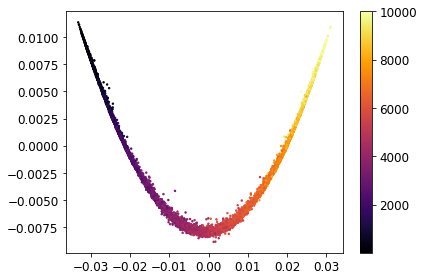

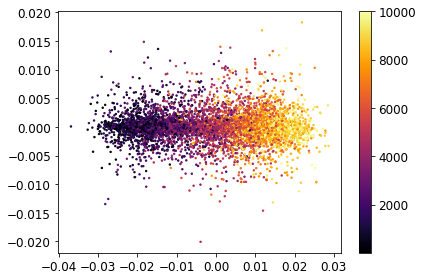

In [13]:
scprep.plot.scatter2d(true_cell_data_phate, trajectory_data['pseudotime'], )
scprep.plot.scatter2d(cell_data_phate, trajectory_data['pseudotime'],)

<AxesSubplot:>

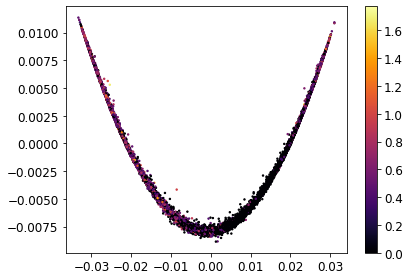

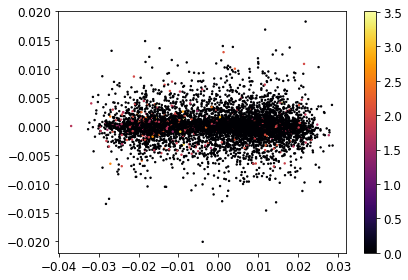

In [14]:
scprep.plot.scatter2d(true_cell_data_phate, true_counts[:, 3422], filename='figures/noiseless_gene.png', dpi=200)
scprep.plot.scatter2d(cell_data_phate, data[:, 3422], filename='figures/noisy_gene.png', dpi=200)

In [15]:
embedding = np.load(f'../results/coexpression/GSPA_QR/0_results.npz')['signal_embedding']
localization_score = np.load(f'../results/coexpression/GSPA_QR/0_results.npz')['localization_score']

In [16]:
gene_phate_op = phate.PHATE(random_state=1234)
gene_data_phate = gene_phate_op.fit_transform(embedding)

Calculating PHATE...
  Running PHATE on 8821 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.13 seconds.
    Calculating KNN search...
    Calculated KNN search in 7.05 seconds.
    Calculating affinities...
    Calculated affinities in 5.94 seconds.
  Calculated graph and diffusion operator in 13.14 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 1.36 seconds.
    Calculating KMeans...
    Calculated KMeans in 6.54 seconds.
  Calculated landmark operator in 9.05 seconds.
  Calculating optimal t...
    Automatically selected t = 6
  Calculated optimal t in 1.61 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.23 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.80 seconds.
Calculated PHATE in 28.85 seconds.


In [17]:
gene_clusters = phate.cluster.kmeans(gene_phate_op, n_clusters=5, random_state=1234)
gene_clusters = scprep.utils.sort_clusters_by_values(gene_clusters, gene_data_phate[:, 0])

In [19]:
magic_op = magic.MAGIC(random_state=1234)
data_magic = magic_op.fit_transform(true_counts)

Calculating MAGIC...
  Running MAGIC on 10000 cells and 8821 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 5.44 seconds.
    Calculating KNN search...
    Calculated KNN search in 10.47 seconds.
    Calculating affinities...
    Calculated affinities in 9.79 seconds.
  Calculated graph and diffusion operator in 25.71 seconds.
  Running MAGIC with `solver='exact'` on 8821-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 4.76 seconds.
Calculated MAGIC in 30.52 seconds.


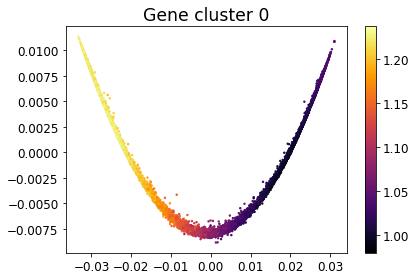

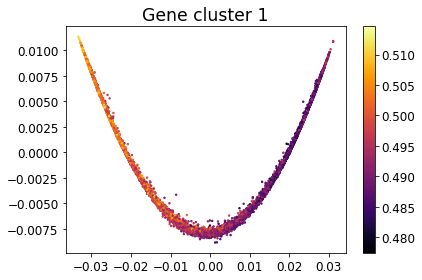

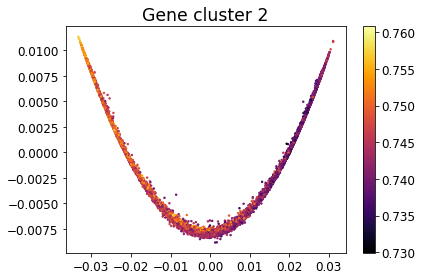

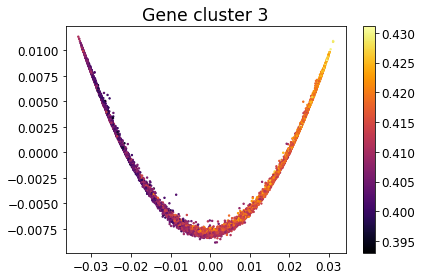

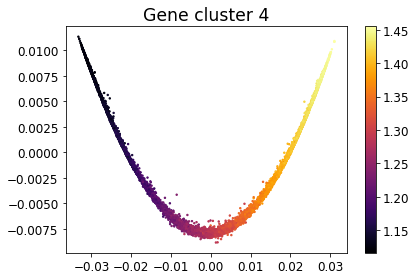

In [20]:
for c in np.unique(gene_clusters):
    scprep.plot.scatter2d(true_cell_data_phate,
                          c=data_magic[:, gene_clusters == c].mean(axis=1),
                          title=f'Gene cluster {c}', filename=f'figures/gene_cluster_{c}.png', dpi=200)

<AxesSubplot:>

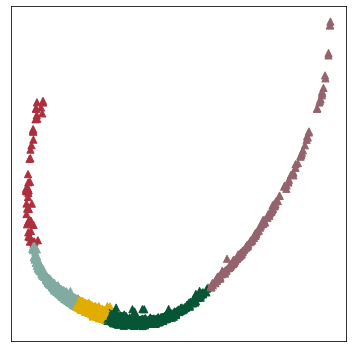

In [21]:
scprep.plot.scatter2d(gene_data_phate, marker='^',
                      c=[colors[cmap[x]] for x in gene_clusters],
                      discrete=True, s=50, ticks=None, figsize=(5,5), filename='figures/GSPA_QR_gene_clusters.png', dpi=200)

<ipython-input-23-f77c70c0821f>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], ci='sd')
<ipython-input-23-f77c70c0821f>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], ci='sd')
<ipython-input-23-f77c70c0821f>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], ci='sd')
<ipython-input-23-f77c70c0821f>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], ci='sd')
<ipython-input-23-f77c70c0821f>:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x=np.round(time, 1), y=signal, co

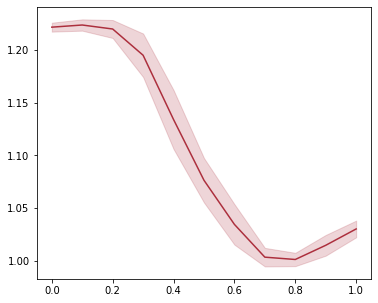

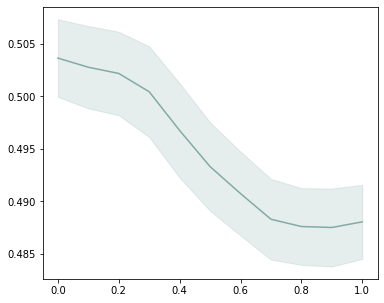

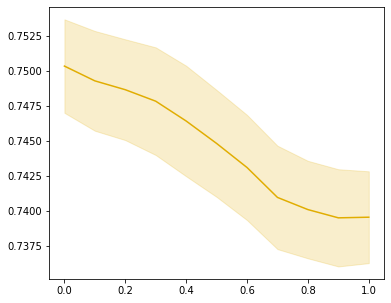

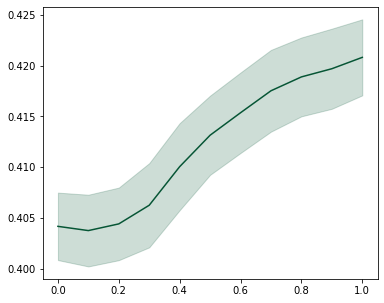

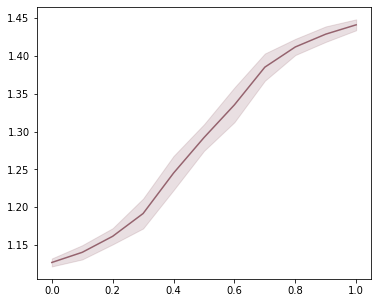

In [23]:
for c in np.unique(gene_clusters):
    fig = plt.figure(figsize=(6,5))
    signal = data_magic[:, gene_clusters == c].mean(axis=1)
    sns.lineplot(x=np.round(time, 1), y=signal, color=colors[cmap[c]], ci='sd')
    fig.savefig(f'figures/gene_cluster_{c}_over_time.png', dpi=200)

## Embeddings for all approaches

2023-08-28 17:10:08,256:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:10:08,259:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


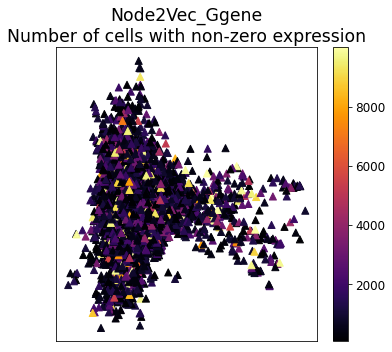

2023-08-28 17:11:38,014:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:11:38,016:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

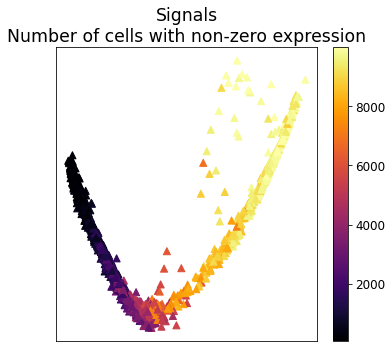

2023-08-28 17:12:55,560:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:12:55,562:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

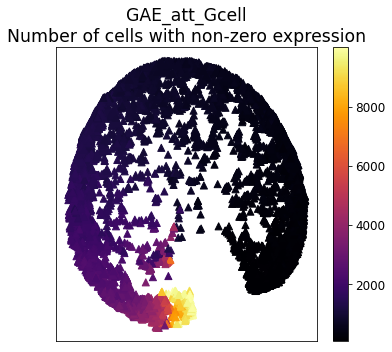

2023-08-28 17:14:17,287:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:14:17,289:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

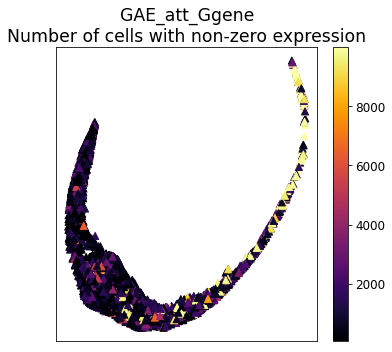

2023-08-28 17:15:39,815:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:15:39,817:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

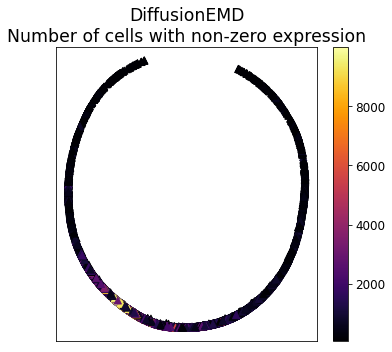

2023-08-28 17:17:00,678:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:17:00,680:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

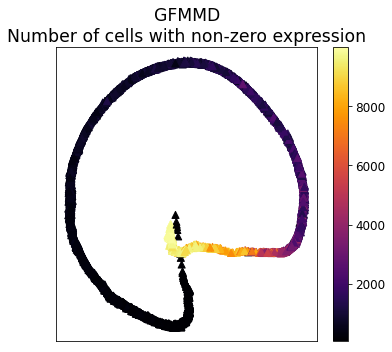

2023-08-28 17:18:19,984:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:18:19,986:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

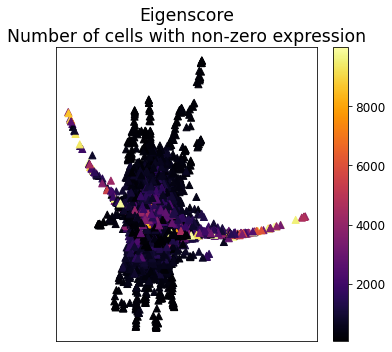

2023-08-28 17:19:51,172:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:19:51,173:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

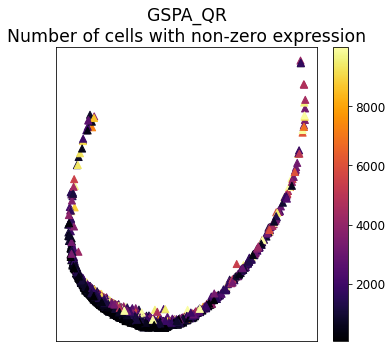

2023-08-28 17:21:04,037:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:21:04,039:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

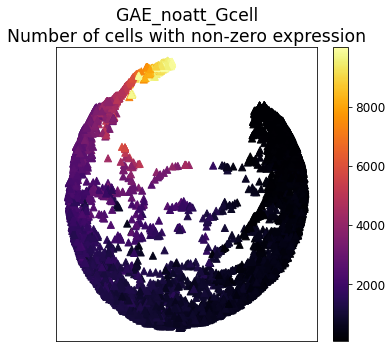

2023-08-28 17:22:33,264:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:22:33,266:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

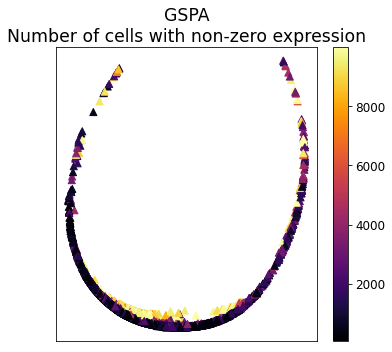

2023-08-28 17:24:02,884:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:24:02,886:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

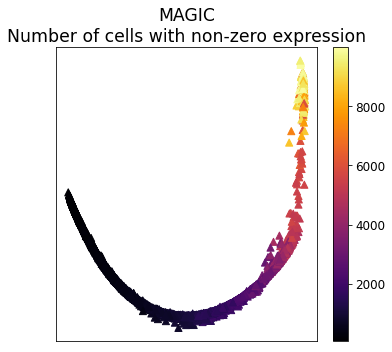

2023-08-28 17:25:11,880:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:25:11,883:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

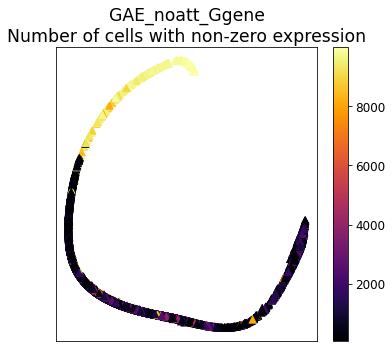

2023-08-28 17:26:40,888:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.
2023-08-28 17:26:40,891:[WARNING](pygsp.graphs.graph.compute_fourier_basis): Computing the full eigendecomposition of a large matrix (8821 x 8821) may take some time.


<Figure size 432x288 with 0 Axes>

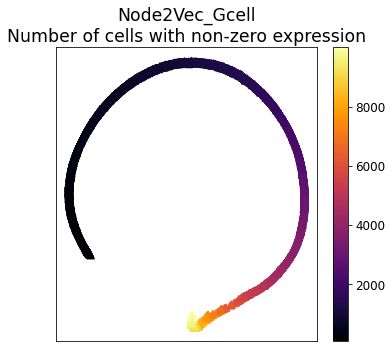

<Figure size 432x288 with 0 Axes>

In [91]:
corr_with_fiedler = {}
for method in os.listdir('../results/coexpression'):
    results = np.load(f'../results/coexpression/{method}/0_results.npz')
    
    gene_phate_op = phate.PHATE(random_state=1234, verbose=False, use_pygsp=True)
    gene_data_phate = gene_phate_op.fit_transform(results['signal_embedding'])
    fiedler = gene_phate_op.graph.U[:, 1]
    corr_with_fiedler[method] = [pearsonr(fiedler, (data > 0).sum(axis=0)).statistic,
                                 pearsonr(fiedler, data.mean(axis=0)).statistic]
    
    scprep.plot.scatter2d(gene_data_phate, marker='^',
                      c=(data > 0).sum(axis=0), s=50, ticks=None, figsize=(5,5),
                          title=method + '\nNumber of cells with non-zero expression',
                      filename=f'figures/{method}_num_cells.png', dpi=200, discrete=False)
    
    
    
    plt.show(); plt.clf()

In [92]:
df = np.abs(pd.DataFrame(corr_with_fiedler)).T.reset_index()

In [93]:
df = df[~df['index'].str.contains('Gcell')].loc[[7,1,11,5,4,9,10,6,3,0]]

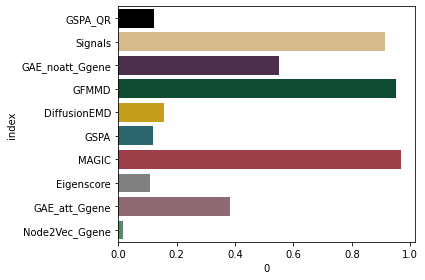

In [105]:
ax = sns.barplot(data=df, y='index', x=0, palette=[colors[x] for x in clist][:10], orient='h')
fig = ax.get_figure()
plt.tight_layout()
fig.savefig('figures/fiedler_corr_with_num_cells_expressed.png', dpi=200)

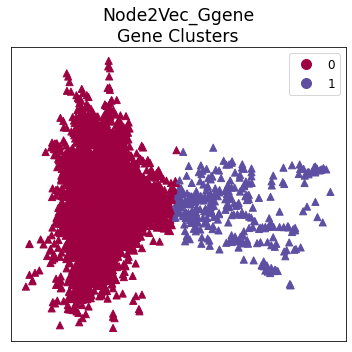

<Figure size 432x288 with 0 Axes>

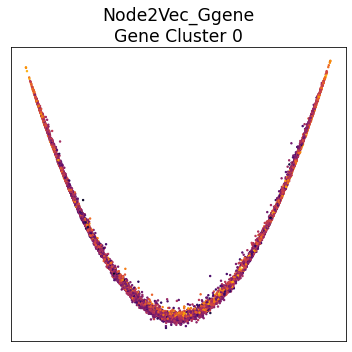

<Figure size 432x288 with 0 Axes>

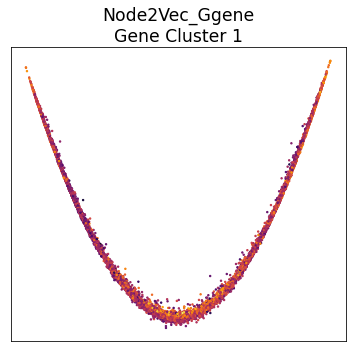

<Figure size 432x288 with 0 Axes>

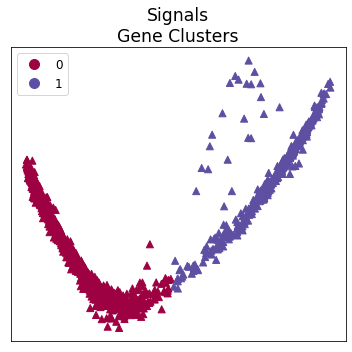

<Figure size 432x288 with 0 Axes>

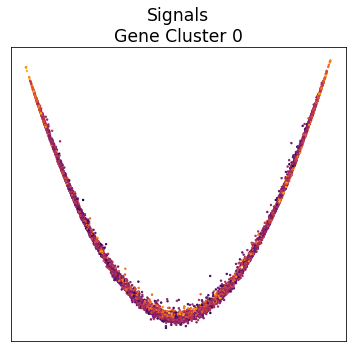

<Figure size 432x288 with 0 Axes>

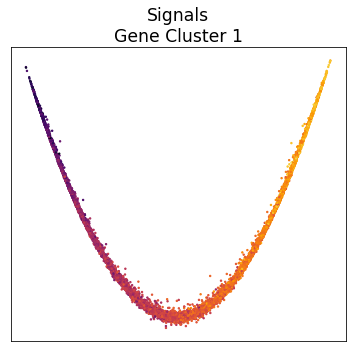

<Figure size 432x288 with 0 Axes>

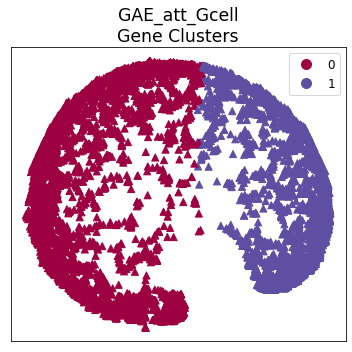

<Figure size 432x288 with 0 Axes>

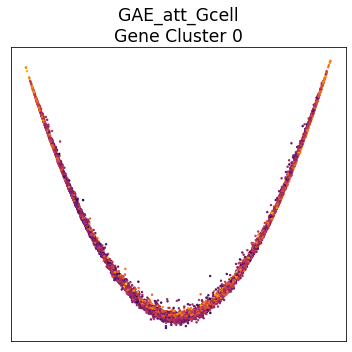

<Figure size 432x288 with 0 Axes>

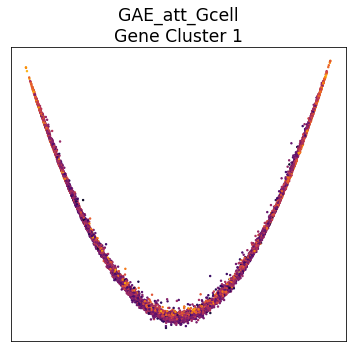

<Figure size 432x288 with 0 Axes>

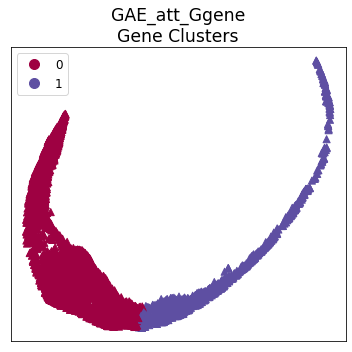

<Figure size 432x288 with 0 Axes>

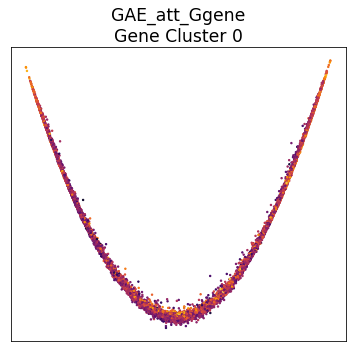

<Figure size 432x288 with 0 Axes>

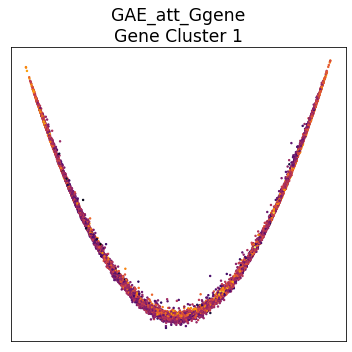

<Figure size 432x288 with 0 Axes>

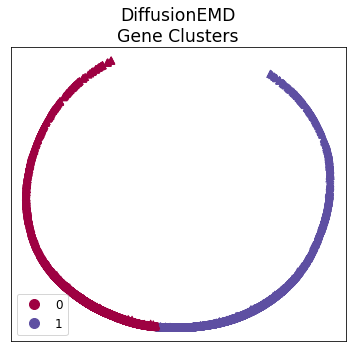

<Figure size 432x288 with 0 Axes>

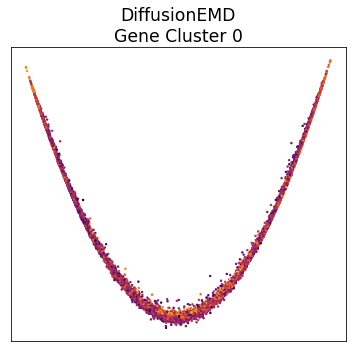

<Figure size 432x288 with 0 Axes>

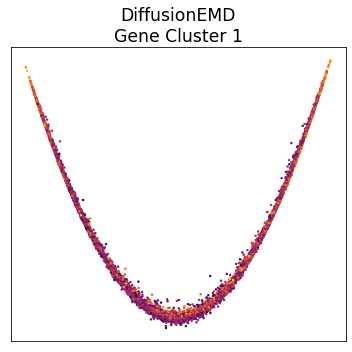

<Figure size 432x288 with 0 Axes>

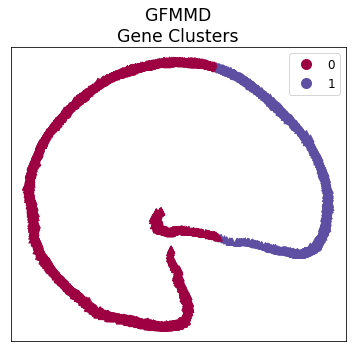

<Figure size 432x288 with 0 Axes>

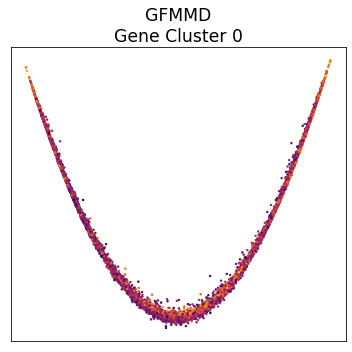

<Figure size 432x288 with 0 Axes>

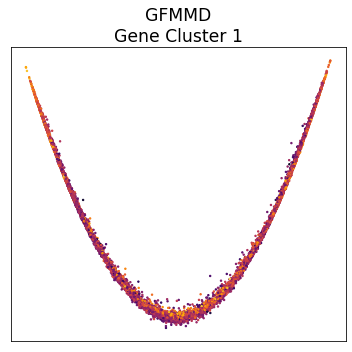

<Figure size 432x288 with 0 Axes>

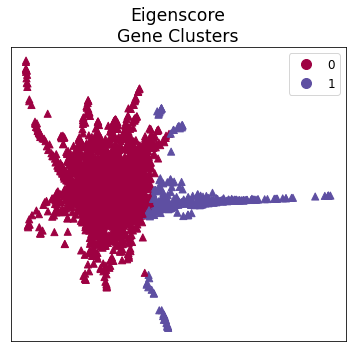

<Figure size 432x288 with 0 Axes>

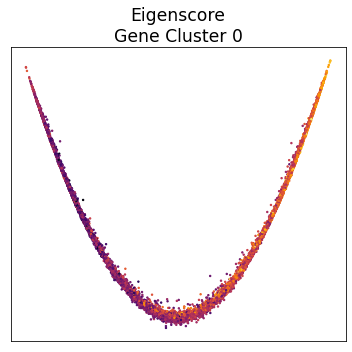

<Figure size 432x288 with 0 Axes>

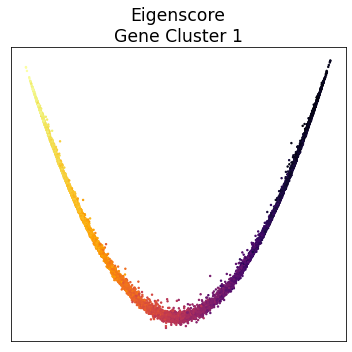

<Figure size 432x288 with 0 Axes>

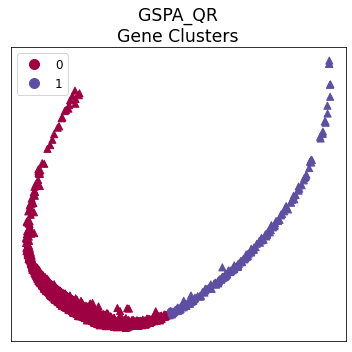

<Figure size 432x288 with 0 Axes>

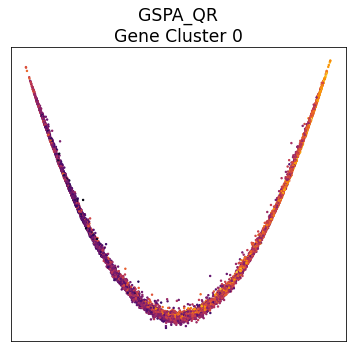

<Figure size 432x288 with 0 Axes>

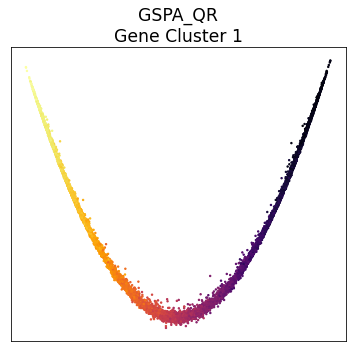

<Figure size 432x288 with 0 Axes>

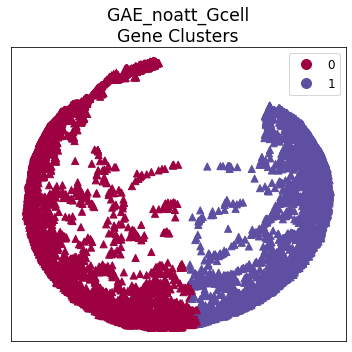

<Figure size 432x288 with 0 Axes>

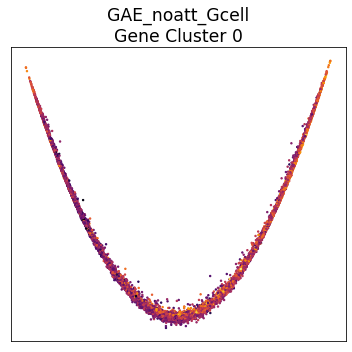

<Figure size 432x288 with 0 Axes>

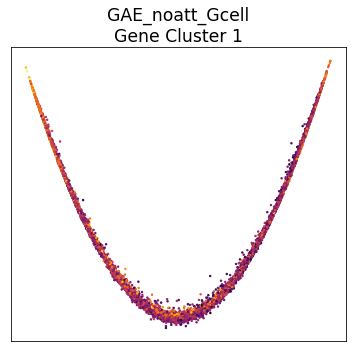

<Figure size 432x288 with 0 Axes>

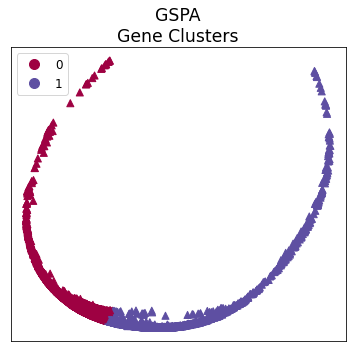

<Figure size 432x288 with 0 Axes>

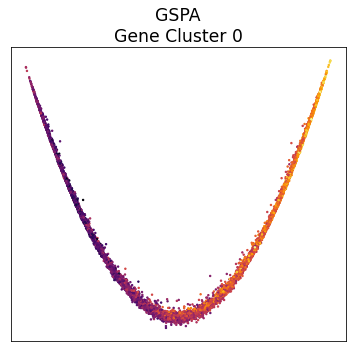

<Figure size 432x288 with 0 Axes>

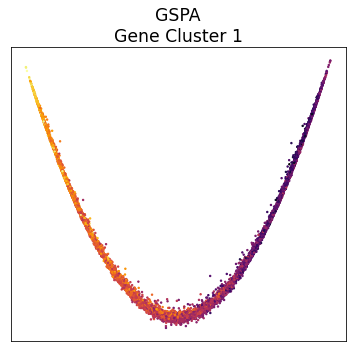

<Figure size 432x288 with 0 Axes>

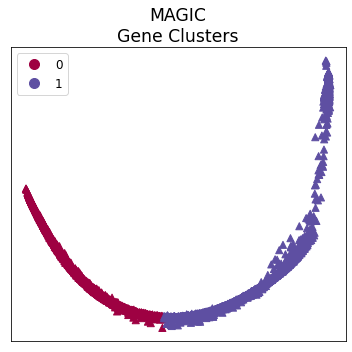

<Figure size 432x288 with 0 Axes>

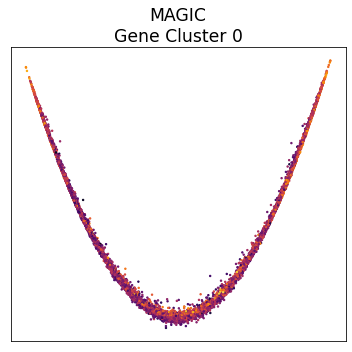

<Figure size 432x288 with 0 Axes>

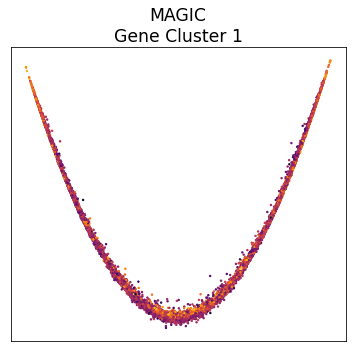

<Figure size 432x288 with 0 Axes>

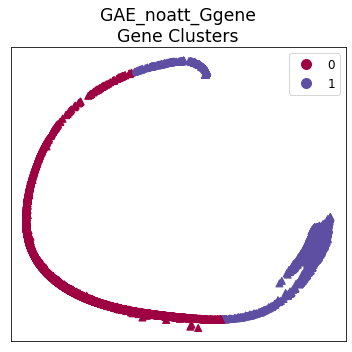

<Figure size 432x288 with 0 Axes>

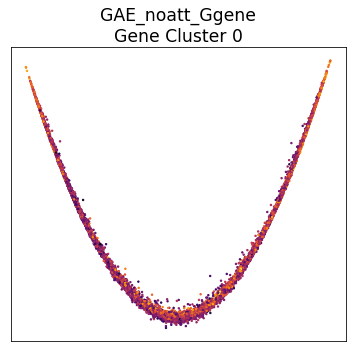

<Figure size 432x288 with 0 Axes>

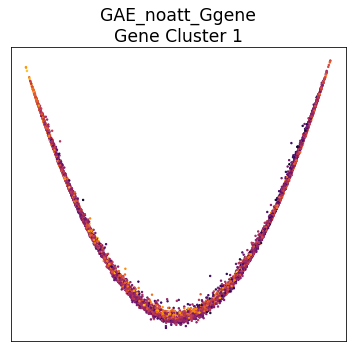

<Figure size 432x288 with 0 Axes>

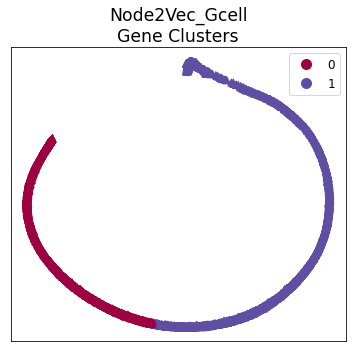

<Figure size 432x288 with 0 Axes>

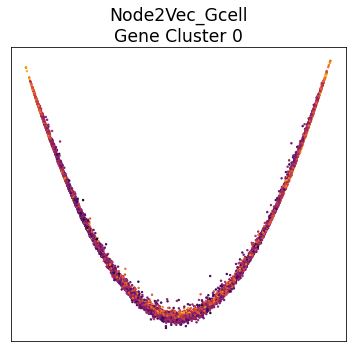

<Figure size 432x288 with 0 Axes>

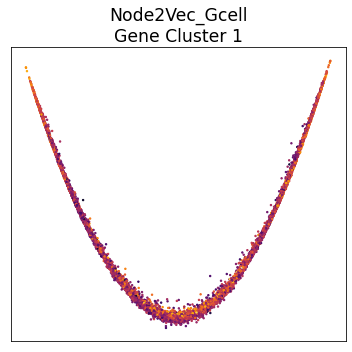

<Figure size 432x288 with 0 Axes>

In [53]:
for method in os.listdir('../results/coexpression'):
    results = np.load(f'../results/coexpression/{method}/0_results.npz')
    
    gene_phate_op = phate.PHATE(random_state=1234, verbose=False)
    gene_data_phate = gene_phate_op.fit_transform(results['signal_embedding'])
    
    gene_clusters = phate.cluster.kmeans(gene_phate_op, n_clusters=2, random_state=1234)
    gene_clusters = scprep.utils.sort_clusters_by_values(gene_clusters, gene_data_phate[:, 0])
    
    scprep.plot.scatter2d(gene_data_phate, marker='^',
                      c=gene_clusters, s=50, ticks=None, figsize=(5,5), cmap='Spectral',
                          title=method + '\nGene Clusters',
                      filename=f'figures/{method}_gene_clusters.png', dpi=200)
    
    plt.show(); plt.clf()
    
    for c in np.unique(gene_clusters):
        scprep.plot.scatter2d(true_cell_data_phate,
                          c=data_magic[:, gene_clusters == c].mean(axis=1), colorbar=False,
                          title=method + f'\nGene Cluster {c}', figsize=(5,5), ticks=None,
                          filename=f'figures/{method}_gene_cluster_{c}.png')
        
        plt.show(); plt.clf()